# Earthquake Alert Prediction

### Objective: 
Build a machine learning model to predict earthquake alert levels using earthquake characteristics.

### Target: 
Alert

### Problem type : 
Multi-class classification

### Classes:
- green
- yellow
- orange
- red


# Importing the libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

# Data Understanding

## Load dataset

In [2]:
df= pd.read_csv(r"C:\Users\Nandana\OneDrive\Desktop\Strydo_internship\PROJECT\DATASET\earthquake_data.csv")

## Basic Inspection

In [3]:
print(df.head())

                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  longitude                  location continent          

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      782 non-null    object 
 1   magnitude  782 non-null    float64
 2   date_time  782 non-null    object 
 3   cdi        782 non-null    int64  
 4   mmi        782 non-null    int64  
 5   alert      415 non-null    object 
 6   tsunami    782 non-null    int64  
 7   sig        782 non-null    int64  
 8   net        782 non-null    object 
 9   nst        782 non-null    int64  
 10  dmin       782 non-null    float64
 11  gap        782 non-null    float64
 12  magType    782 non-null    object 
 13  depth      782 non-null    float64
 14  latitude   782 non-null    float64
 15  longitude  782 non-null    float64
 16  location   777 non-null    object 
 17  continent  206 non-null    object 
 18  country    484 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 1

In [5]:
print(df.shape)

(782, 19)


In [6]:
print(df.columns)

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')


In [7]:
print(df.describe())

        magnitude         cdi         mmi     tsunami          sig  \
count  782.000000  782.000000  782.000000  782.000000   782.000000   
mean     6.941125    4.333760    5.964194    0.388747   870.108696   
std      0.445514    3.169939    1.462724    0.487778   322.465367   
min      6.500000    0.000000    1.000000    0.000000   650.000000   
25%      6.600000    0.000000    5.000000    0.000000   691.000000   
50%      6.800000    5.000000    6.000000    0.000000   754.000000   
75%      7.100000    7.000000    7.000000    1.000000   909.750000   
max      9.100000    9.000000    9.000000    1.000000  2910.000000   

              nst        dmin         gap       depth    latitude   longitude  
count  782.000000  782.000000  782.000000  782.000000  782.000000  782.000000  
mean   230.250639    1.325757   25.038990   75.883199    3.538100   52.609199  
std    250.188177    2.218805   24.225067  137.277078   27.303429  117.898886  
min      0.000000    0.000000    0.000000    2.70

In [8]:
print(df.duplicated().sum())

0


## Missing values

In [9]:
print(df.isnull().sum())

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


# Data Cleaning

## Handle target

In [10]:
df = df.dropna(subset=['alert'])  # since supervise learning requires labels, we drop rows where 'alert' is null
print(df.isnull().sum())

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert          0
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    310
country      188
dtype: int64


In [11]:
print(df.shape) #we can see that 367 rows have been dropped since they had null values in the 'alert' column.

(415, 19)


# Handle feature missing values

### Numerical

In [12]:
cat_cols = ['cdi', 'mmi', 'depth']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].median())

### Categorical

In [13]:
cat_cols = ['continent', 'country']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
data = df.drop(columns=['location', 'title'])

# Exploratory Data Analysis

## Target distribution

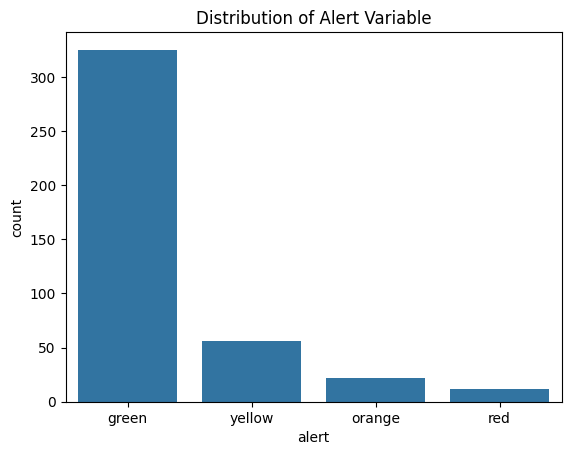

In [15]:
sns.countplot(x='alert', data=df)
plt.title('Distribution of Alert Variable')
plt.show()

#### Observation:
It is evident that the the targets are not equally classified and class 0 has many data because of which teh dataset is imbalanced.

## Correlation Matrix

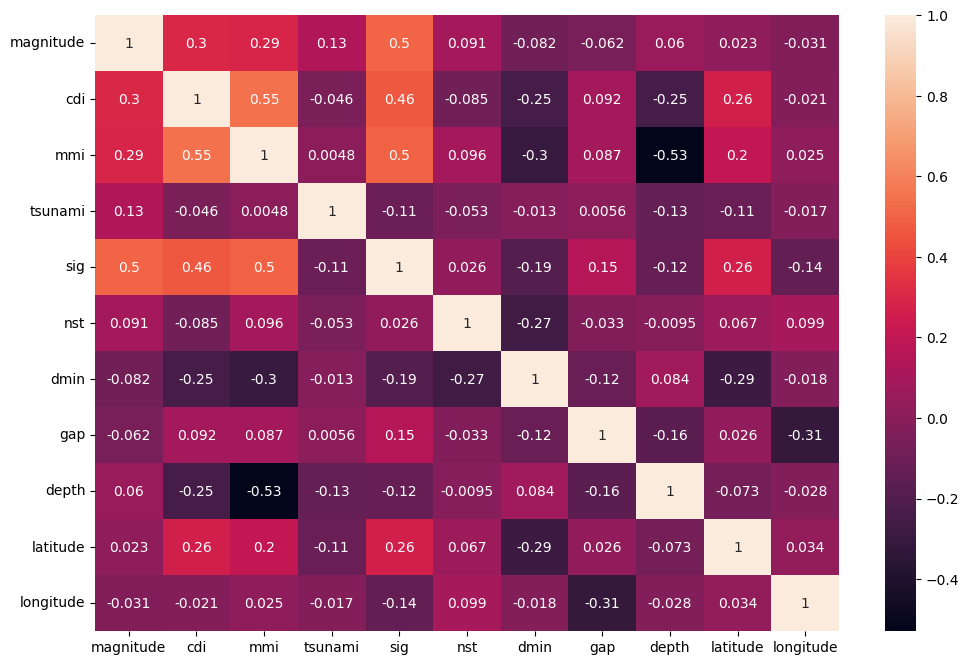

In [16]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)
plt.show()

In [17]:
inv_corr = np.linalg.inv(corr)
r_squared = (1 - (1 / np.diag(inv_corr)))
vif=1/(1-r_squared)
vif_df = pd.DataFrame({'Feature': corr.columns, 'VIF': vif})
print("Redundancy Features:\n")
print( r_squared)
print("\n")
print("Variance Inflation Factors:\n")
print(vif_df)

Redundancy Features:

[0.36677337 0.39842123 0.57043154 0.10842594 0.48143307 0.13768089
 0.23022554 0.16530282 0.37787645 0.16811842 0.1323499 ]


Variance Inflation Factors:

      Feature       VIF
0   magnitude  1.579213
1         cdi  1.662293
2         mmi  2.327918
3     tsunami  1.121612
4         sig  1.928391
5         nst  1.159664
6        dmin  1.299082
7         gap  1.198039
8       depth  1.607398
9    latitude  1.202094
10  longitude  1.152538


#### Observation:

1. from the correlation plot targets closer to Alerts are cdi, mmi, sig
2. No redundancy (since the |correlation| !> 0.8 and the VIF is less than 5)


## Box plot

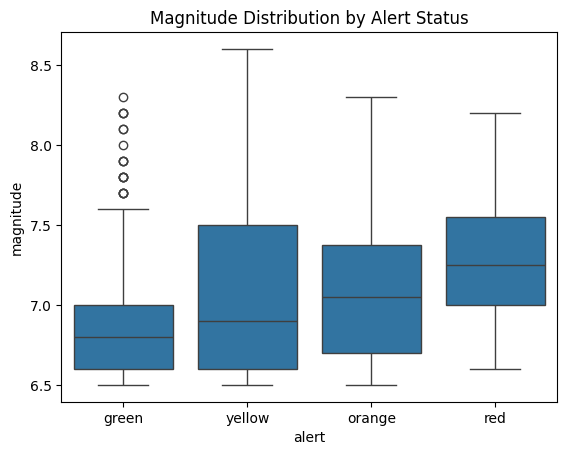

In [18]:
sns.boxplot(
    x='alert',
    y='magnitude',
    data=df
)
plt.title('Magnitude Distribution by Alert Status')
plt.show()

# Encoding

### Encode : Target

In [19]:
le = LabelEncoder()

df['alert'] = le.fit_transform(
    df['alert']
)

### Encode : Features

In [20]:
data = df.drop(
    columns=[
        'title',
        'location',
        'date_time'
    ],
    errors='ignore'
)

In [21]:
data = pd.get_dummies(
    data,
    columns=[
        'country',
        'continent',
        'net',
        'magType'
    ]
)

# Prepare Data

## Feature Selection

In [22]:
X = data.drop('alert', axis=1)
y = data['alert']

## Stratified Split


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# BaseLine Model

## Random Forest Classification

In [24]:
rf = RandomForestClassifier(
    random_state=42
)

In [25]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
rf_pred = rf.predict(X_test)

### Evaluation

In [27]:
# accuracy
accuracy = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.83


In [28]:
#classification report
print("Classification Report:")
print(classification_report(y_test, rf_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.92        98
           1       0.67      0.29      0.40         7
           2       1.00      0.67      0.80         3
           3       0.38      0.18      0.24        17

    accuracy                           0.83       125
   macro avg       0.73      0.53      0.59       125
weighted avg       0.79      0.83      0.80       125



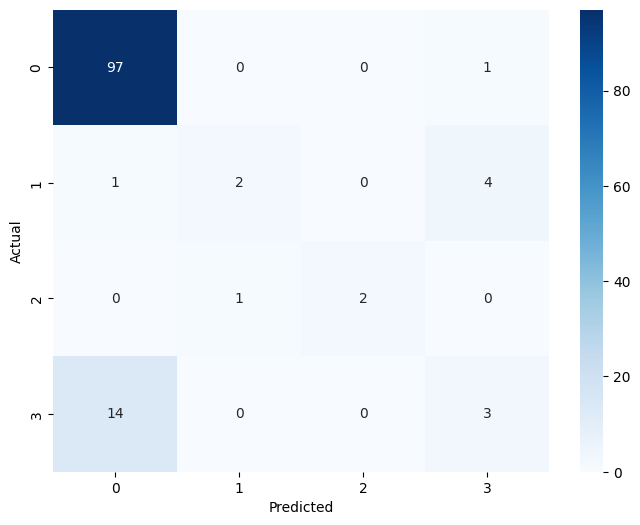

In [29]:
# confusion matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Model Diagnosis

## Overfitting check

In [30]:
rf_train_pred = rf.predict(X_train)

train_acc = accuracy_score(y_train, rf_train_pred)
test_acc = accuracy_score(y_test, rf_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.832


In [31]:
rf_train_acc = accuracy_score(
    y_train,
    rf_train_pred
)

## Feature Importance

In [32]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "RF": rf.feature_importances_
})

# Handle Imbalance

## SMOTE (Synthetic Minority Over Sampling Technique)

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

## Retrain random forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf_smote = RandomForestClassifier(
    random_state=42
)
rf_smote.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
rf_smote_pred = rf_smote.predict(X_test)

### Evaluating the model

In [37]:
# accuracy
accuracy = accuracy_score(y_test, rf_smote_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.85


In [38]:
#classification report
print("Classification Report:")
print(classification_report(y_test, rf_smote_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94        98
           1       0.43      0.43      0.43         7
           2       1.00      1.00      1.00         3
           3       0.48      0.71      0.57        17

    accuracy                           0.85       125
   macro avg       0.72      0.76      0.73       125
weighted avg       0.88      0.85      0.86       125



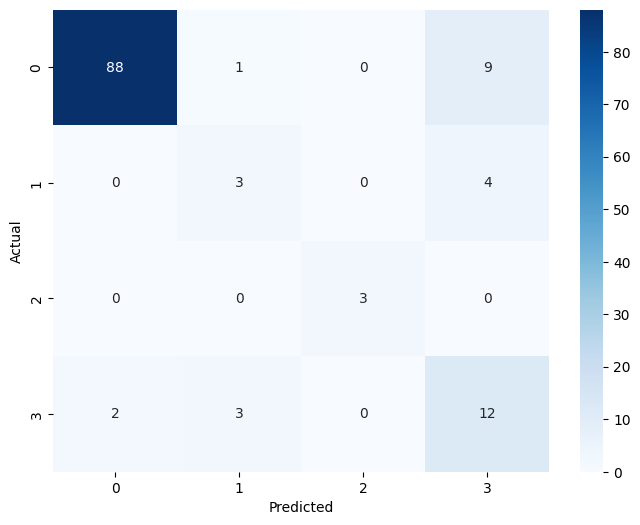

In [39]:
# confusion matrix
cm = confusion_matrix(y_test, rf_smote_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Overfitting check

In [40]:
rf_smote_train_pred = rf_smote.predict(
    X_train_smote
)

train_acc = accuracy_score(
    y_train_smote,
    rf_smote_train_pred
)

test_acc = accuracy_score(
    y_test,
    rf_smote_pred
)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.848


In [41]:
rf_smote_train_acc = accuracy_score(
    y_train_smote,
    rf_smote_train_pred
)

In [42]:
rf_smote_importance = pd.DataFrame({
    "Feature": X.columns,
    "RF_SMOTE": rf_smote.feature_importances_
})

# Gridsearch CV

In [43]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5,10]
}

In [44]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='recall_macro'
)

In [45]:
grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
0.5575086266390613


In [46]:
best_model = grid.best_estimator_
grid_pred = best_model.predict(X_test)



In [47]:
# Accuracy
print("Accuracy:",accuracy_score(y_test, grid_pred))


Accuracy: 0.84


In [48]:
# Classification Report
print(classification_report(y_test, grid_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93        98
           1       0.50      0.29      0.36         7
           2       1.00      0.67      0.80         3
           3       0.44      0.24      0.31        17

    accuracy                           0.84       125
   macro avg       0.71      0.54      0.60       125
weighted avg       0.80      0.84      0.81       125



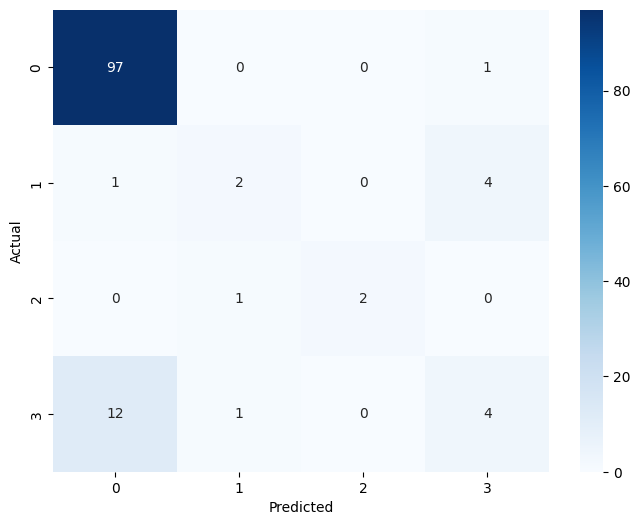

In [49]:
# confusion matrix
cm = confusion_matrix(y_test, grid_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [50]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance_df)

              Feature  Importance
4                 sig    0.178678
2                 mmi    0.142708
9            latitude    0.098100
1                 cdi    0.080059
6                dmin    0.059612
..                ...         ...
51  country_Venezuela    0.000000
52   continent_Africa    0.000000
59             net_ci    0.000000
60             net_hv    0.000000
68        magType_mwc    0.000000

[70 rows x 2 columns]


In [51]:
train_pred = best_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, grid_pred)

print("Train:", train_acc)
print("Test:", test_acc)

Train: 0.993103448275862
Test: 0.84


# Decision tree with SMOTE

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_smote, y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
dt_pred = dt_model.predict(X_test)

In [55]:
dt_train_pred = dt_model.predict(X_train_smote)

In [56]:
# Accuracy
print("Accuracy:",accuracy_score(y_test, dt_pred))


Accuracy: 0.752


In [57]:
# Classification Report
print(classification_report(y_test,dt_pred))

              precision    recall  f1-score   support

           0       0.92      0.85      0.88        98
           1       0.36      0.71      0.48         7
           2       1.00      0.67      0.80         3
           3       0.21      0.24      0.22        17

    accuracy                           0.75       125
   macro avg       0.62      0.62      0.60       125
weighted avg       0.80      0.75      0.77       125



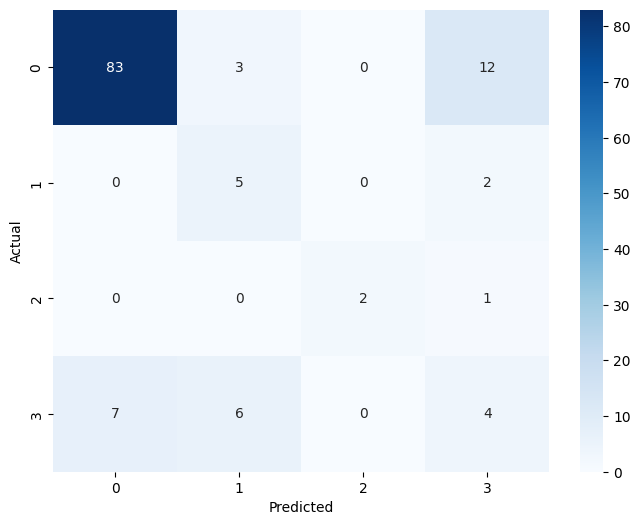

In [58]:
# confusion matrix
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Overfitting check

In [59]:
dt_train_pred = dt_model.predict(
    X_train_smote
)

dt_train_acc = accuracy_score(
    y_train_smote,
    dt_train_pred
)

dt_test_acc = accuracy_score(
    y_test,
    dt_pred
)

print("Train Accuracy:", dt_train_acc)
print("Test Accuracy:", dt_test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.752


In [60]:
dt_train_acc = accuracy_score(
    y_train_smote,
    dt_train_pred
)

In [61]:
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "DT": dt_model.feature_importances_
})

# Logistic regression with SMOTE

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [64]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [65]:
lr_pred = lr_model.predict(X_test_scaled)

In [66]:
lr_train_pred = lr_model.predict(
    X_train_scaled
)

lr_train_acc = accuracy_score(
    y_train_smote,
    lr_train_pred
)

lr_test_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Train Accuracy:", lr_train_acc)
print("Test Accuracy:", lr_test_acc)

Train Accuracy: 0.9779735682819384
Test Accuracy: 0.824


In [67]:
lr_train_acc = accuracy_score(
    y_train_smote,
    lr_train_pred
)

In [68]:
# Accuracy
print("Accuracy:",accuracy_score(y_test, lr_pred))


Accuracy: 0.824


In [69]:
# Classification Report
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.92        98
           1       0.38      0.43      0.40         7
           2       0.67      0.67      0.67         3
           3       0.46      0.35      0.40        17

    accuracy                           0.82       125
   macro avg       0.60      0.60      0.60       125
weighted avg       0.81      0.82      0.82       125



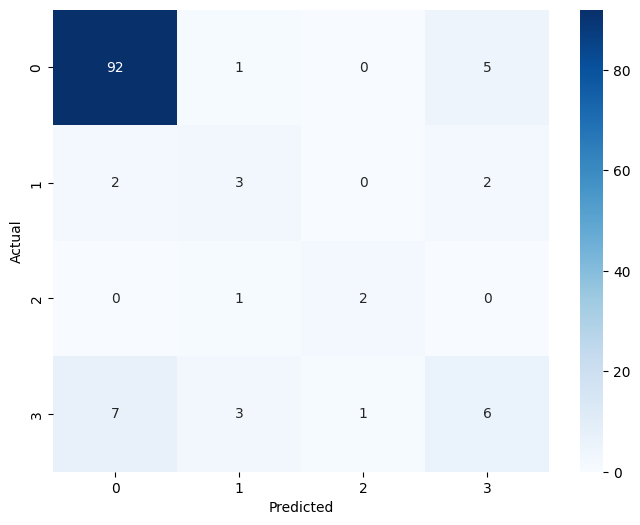

In [70]:
# confusion matrix
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# XG Boost with SMOTE

In [71]:
from xgboost import XGBClassifier

In [72]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

In [73]:
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [74]:
xgb_pred = xgb_model.predict(X_test)

In [75]:
xgb_train_pred = xgb_model.predict(
    X_train_smote
)

xgb_train_acc = accuracy_score(
    y_train_smote,
    xgb_train_pred
)

xgb_test_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("Train Accuracy:", xgb_train_acc)
print("Test Accuracy:", xgb_test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.808


In [76]:
xgb_train_acc = accuracy_score(
    y_train_smote,
    xgb_train_pred
)

In [77]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "XGB": xgb_model.feature_importances_
})

In [78]:
print(classification_report(y_test, xgb_pred) )

              precision    recall  f1-score   support

           0       0.96      0.87      0.91        98
           1       0.42      0.71      0.53         7
           2       1.00      0.67      0.80         3
           3       0.41      0.53      0.46        17

    accuracy                           0.81       125
   macro avg       0.70      0.69      0.67       125
weighted avg       0.85      0.81      0.82       125



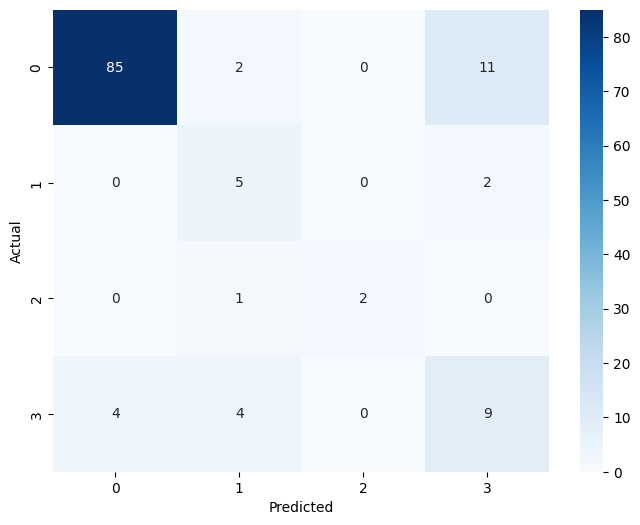

In [79]:
# confusion matrix
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Comparison

In [80]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# Predictions from all models
models = {
    "RF": rf_pred,
    "RF + SMOTE": rf_smote_pred,
    "Decision Tree": dt_pred,
    "Logistic Regression": lr_pred,
    "XGBoost": xgb_pred
}

# Train accuracies calculated earlier
train_acc_dict = {
    "RF": rf_train_acc,
    "RF + SMOTE": rf_smote_train_acc,
    "Decision Tree": dt_train_acc,
    "Logistic Regression": lr_train_acc,
    "XGBoost": xgb_train_acc
}

results = []

for name, pred in models.items():

    recalls = recall_score(
        y_test,
        pred,
        average=None
    )

    results.append({

        "Model": name,

        "Train Accuracy":
        train_acc_dict[name],

        "Test Accuracy":
        accuracy_score(y_test, pred),

        "Macro Recall":
        recall_score(
            y_test,
            pred,
            average='macro'
        ),

        "Macro F1":
        f1_score(
            y_test,
            pred,
            average='macro'
        ),

        "Class 0 Recall":
        recalls[0],

        "Class 1 Recall":
        recalls[1],

        "Class 2 Recall":
        recalls[2],

        "Class 3 Recall":
        recalls[3]

    })

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Overfitting Analysis
comparison_df["Overfit Gap"] = (
    comparison_df["Train Accuracy"]
    - comparison_df["Test Accuracy"]
)

# Ranking based on Macro F1
comparison_df["Rank"] = (
    comparison_df["Macro F1"]
    .rank(
        ascending=False,
        method="dense"
    )
)

# Sort by Rank
comparison_df = comparison_df.sort_values(
    by="Rank"
).reset_index(drop=True)

# Rearrange Columns
comparison_df = comparison_df[[
    "Rank",
    "Model",
    "Train Accuracy",
    "Test Accuracy",
    "Macro Recall",
    "Macro F1",
    "Class 0 Recall",
    "Class 1 Recall",
    "Class 2 Recall",
    "Class 3 Recall",
    "Overfit Gap"
]]

comparison_df

,Rank,Model,Train Accuracy,Test Accuracy,Macro Recall,Macro F1,Class 0 Recall,Class 1 Recall,Class 2 Recall,Class 3 Recall,Overfit Gap
0,1.0,RF + SMOTE,1.000000,0.848,0.758103,0.734043,0.897959,0.428571,1.000000,0.705882,0.152000
1,2.0,XGBoost,1.000000,0.808,0.694428,0.674236,0.867347,0.714286,0.666667,0.529412,0.192000
2,3.0,Logistic Regression,0.977974,0.824,0.596739,0.597822,0.938776,0.428571,0.666667,0.352941,0.153974
3,4.0,Decision Tree,1.000000,0.752,0.615796,0.595348,0.846939,0.714286,0.666667,0.235294,0.248000
4,5.0,RF,1.000000,0.832,0.529662,0.590952,0.989796,0.285714,0.666667,0.176471,0.168000


# Feature Importance

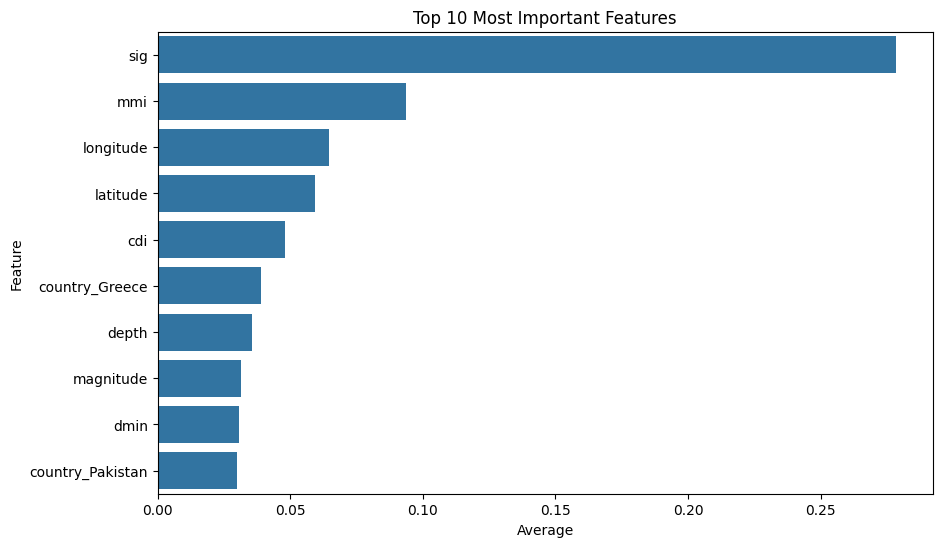

In [81]:
feature_compare = (
    rf_importance
    .merge(
        rf_smote_importance,
        on="Feature"
    )
    .merge(
        dt_importance,
        on="Feature"
    )
    .merge(
        xgb_importance,
        on="Feature"
    )
)

feature_compare.head()

feature_compare["Average"] = (
    feature_compare[
        ["RF","RF_SMOTE","DT","XGB"]
    ].mean(axis=1)
)

feature_compare = feature_compare.sort_values(
    by="Average",
    ascending=False
)

feature_compare.head(15)

# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_compare.head(10),
    x="Average",
    y="Feature"
)

plt.title(
    "Top 10 Most Important Features"
)

plt.show()


The model relies primarily on:
1. Earthquake significance (SIG)
2. Modified Mercalli Intensity (MMI)
3. Community Damage Index (CDI)
4. Location information
5. Depth

# SHAP

In [82]:
import shap

c:\Users\Nandana\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [83]:
explainer = shap.TreeExplainer(
    rf_smote
)

In [84]:
shap_values = explainer.shap_values(
    X_test
)

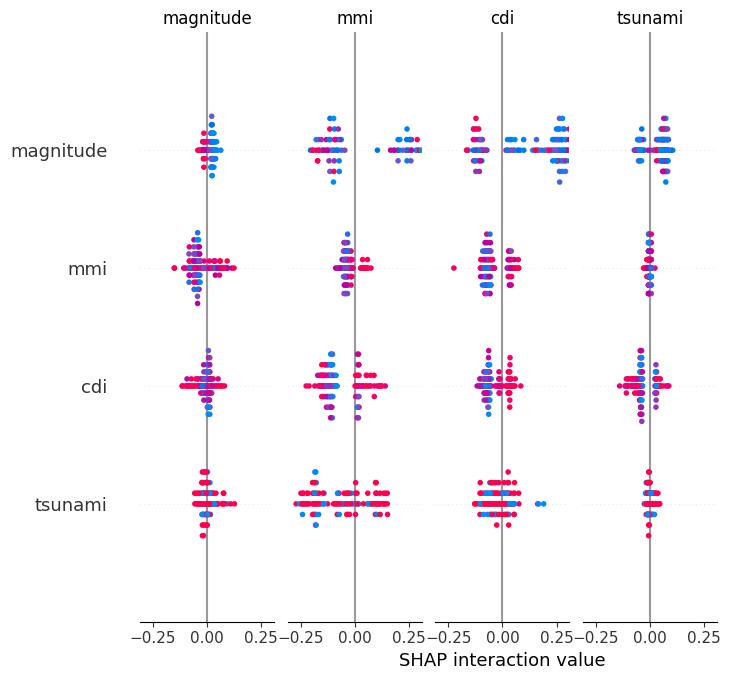

In [85]:
shap.summary_plot(
    shap_values,
    X_test
)

## Explaining Conditions Individually


Alert Class 0


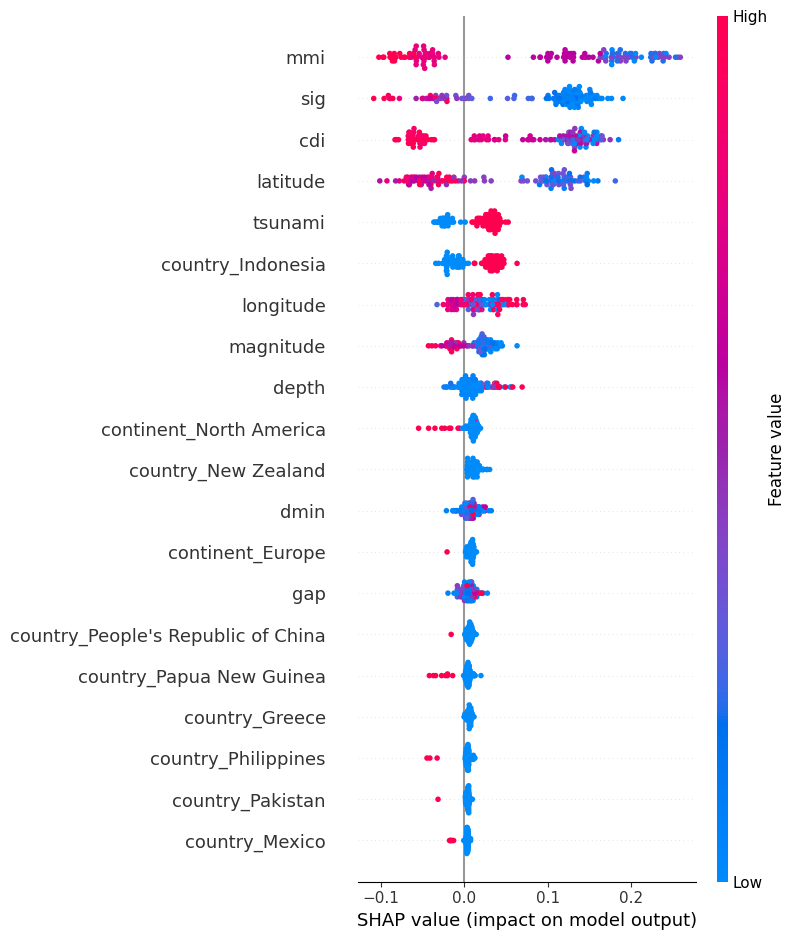


Alert Class 1


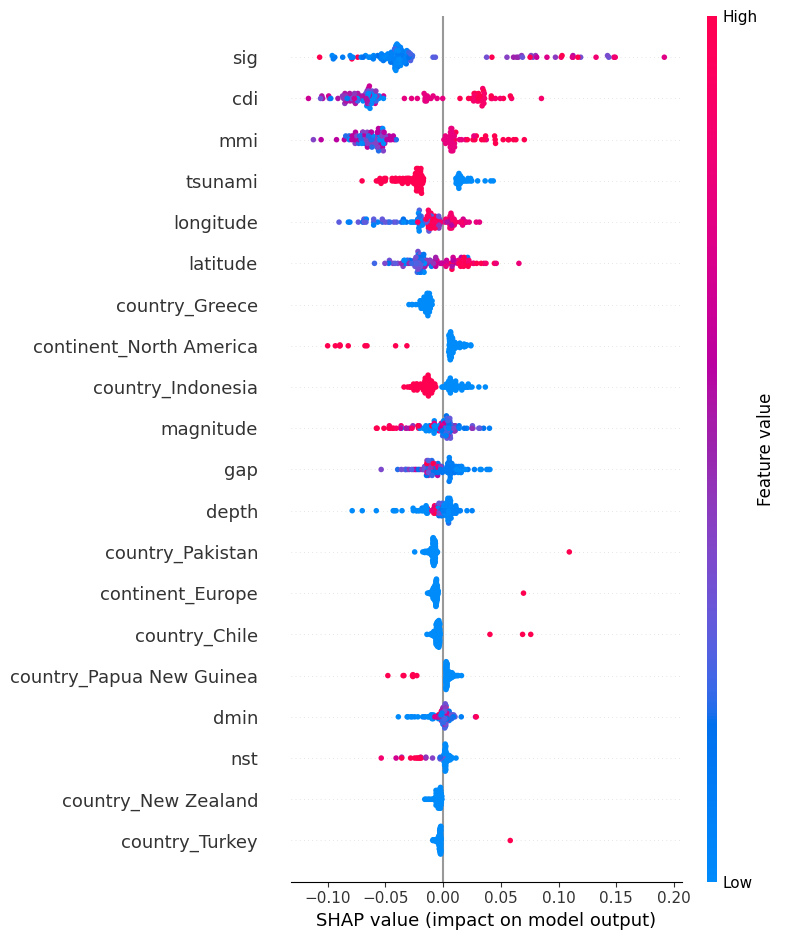


Alert Class 2


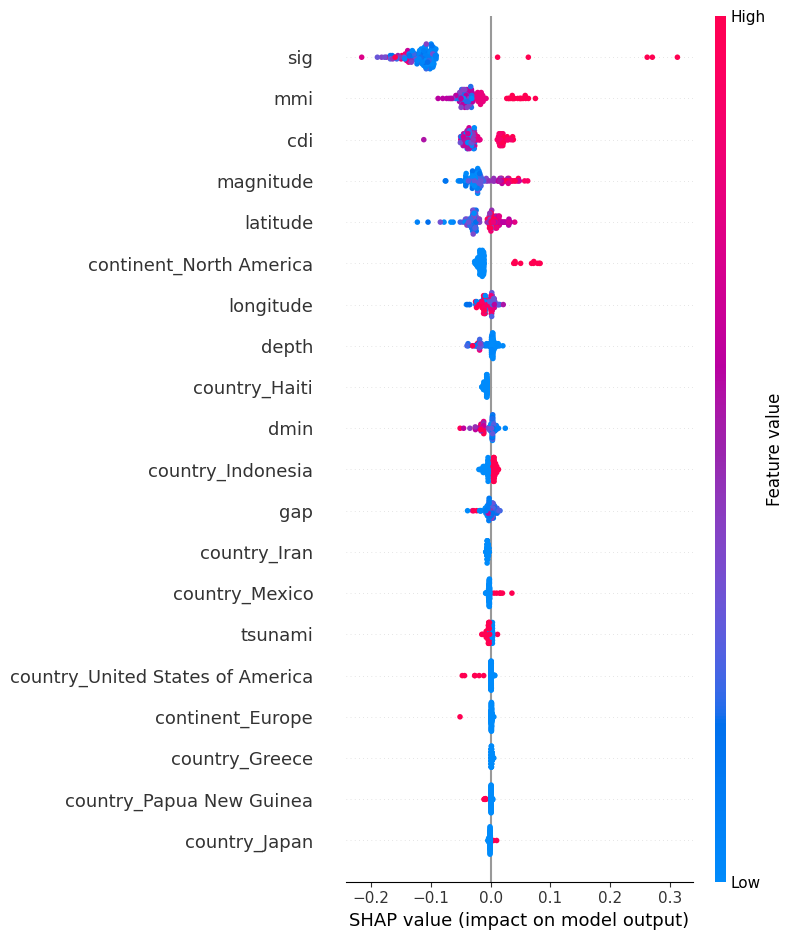


Alert Class 3


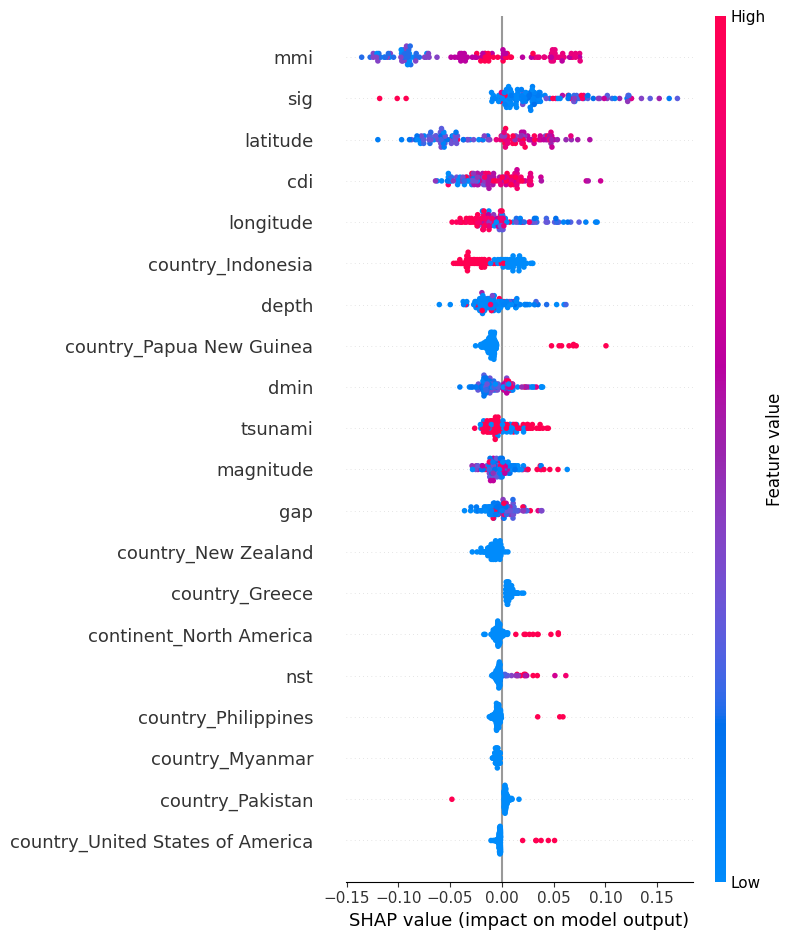

In [86]:
for cls in range(4):

    print(f"\nAlert Class {cls}")

    shap.summary_plot(
        shap_values[:,:,cls],
        X_test
    )

SHAP analysis revealed that SIG, MMI, CDI, and depth were the dominant factors influencing alert prediction. Higher significance and intensity values increased the likelihood of severe alert classes, while deeper earthquakes generally reduced alert severity.

# Rule Extraction

In [87]:
xai_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

xai_tree.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


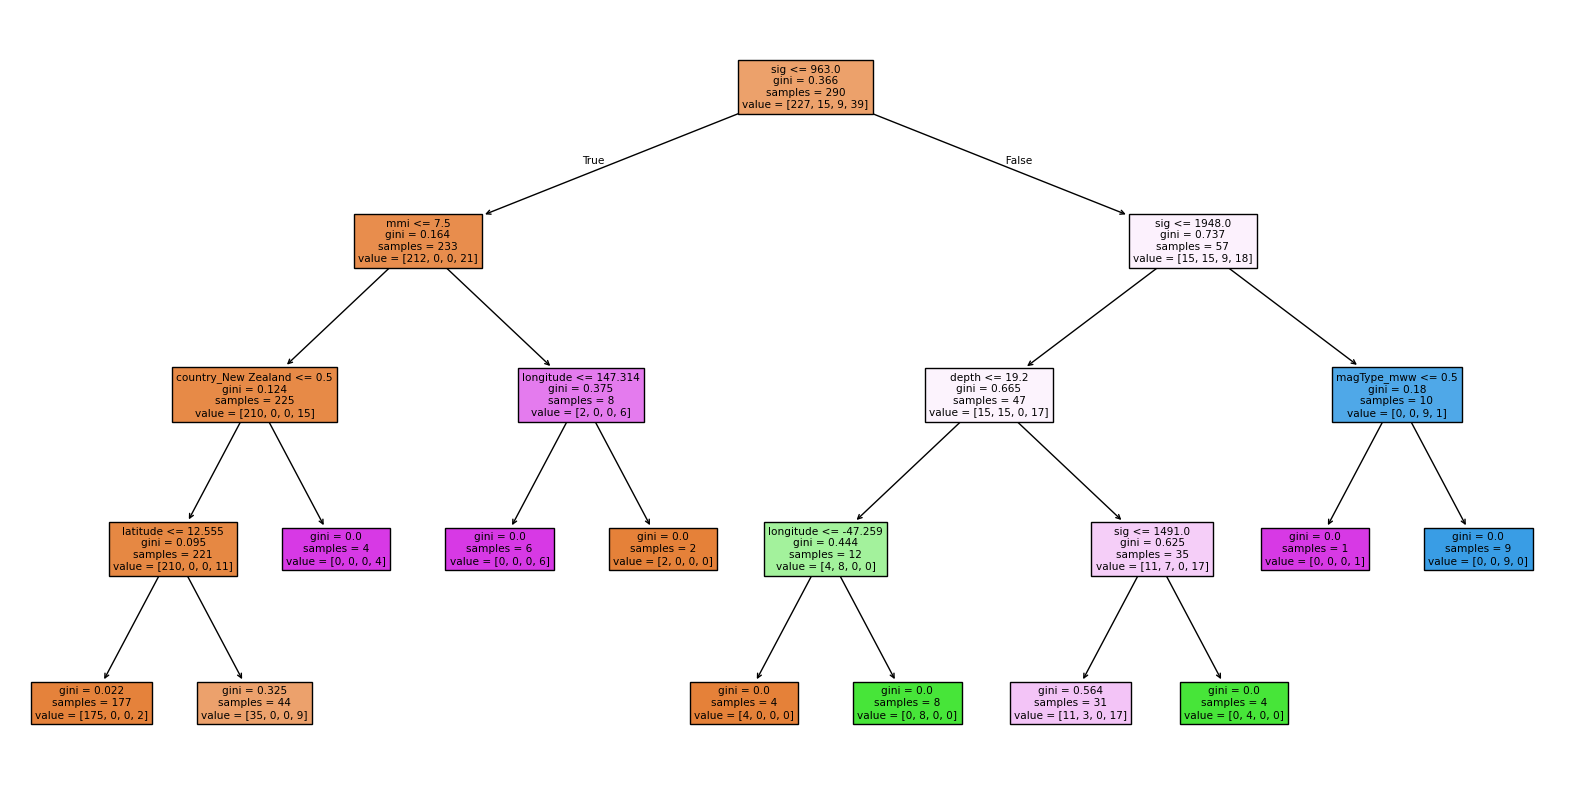

In [88]:
from sklearn.tree import plot_tree

plt.figure(
    figsize=(20,10)
)

plot_tree(
    xai_tree,
    feature_names=X.columns,
    filled=True
)

plt.show()

# Save the best model

In [89]:
import joblib

joblib.dump(
    rf_smote,
    "earthquake_alert_model.pkl"
)

['earthquake_alert_model.pkl']

In [90]:
joblib.dump(
    le,
    "alert_encoder.pkl"
)

['alert_encoder.pkl']

# Conclusion

Random Forest with SMOTE achieved the best overall performance among all tested models. The model obtained the highest Macro F1 score and significantly improved minority class detection. Feature importance analysis revealed that SIG, MMI, CDI, latitude, and longitude were the most influential predictors. SMOTE effectively addressed class imbalance, increasing Class 3 recall substantially compared to the baseline Random Forest model.

Explainable AI techniques were incorporated to improve model transparency. Feature importance and SHAP analysis revealed that earthquake significance (SIG), Modified Mercalli Intensity (MMI), Community Damage Index (CDI), and depth were the primary factors influencing alert prediction. Decision tree rule extraction further provided interpretable decision paths, enabling clear understanding of how alert levels are determined.